# Reverse-direction analysis: Does market variables cause social and news response

This notebook examines whether market variables explain subsequent social-media
and news activity for semiconductor stocks.
The analysis is motivated by weak results obtained when using sentiment and
activity features to predict future market behavior.
Only XGBoost is used because it is robust to nonlinear relationships and does
not require assumptions about multicollinearity among predictors.

## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="ticks", font_scale=1.1)

company_colors = {
    "NVDA": "#4DB6AC",
    "AMD": "#BA68C8",
    "INTC": "#5C9BD5"
}

In [2]:
df = pd.read_csv("datasets/final/initial_processed_dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["company", "date"]).reset_index(drop=True)

print(f"Shape    : {df.shape}")
print(f"Period   : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Companies: {df['company'].unique().tolist()}")

Shape    : (7413, 69)
Period   : 2016-05-31 to 2026-03-27
Companies: ['AMD', 'INTC', 'NVDA']


## 2. Define social and news variables

The following variables represent social-media and news response:

 - Reddit post activity
 - Reddit comment activity
 - News coverage
 - Reddit sentiment
 - News sentiment

 The goal is to predict their next-day values using only market-related variables.

In [3]:
SENTIMENT_COLS = [
    "reddit_sentiment",
    "news_sentiment"
]

ACTIVITY_COLS = [
    "reddit_post_count",
    "reddit_comment_count",
    "news_count"
]

SOCIAL_NEWS_COLS = SENTIMENT_COLS + ACTIVITY_COLS

BASE_REVERSE_TARGETS = SOCIAL_NEWS_COLS.copy()

BASE_REVERSE_TARGETS = [
    col for col in BASE_REVERSE_TARGETS
    if col in df.columns
]

print("Available social/news variables:")
print(BASE_REVERSE_TARGETS)

Available social/news variables:
['reddit_sentiment', 'news_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_count']


## 3. Create next-day social/news targets

For each company separately, the social/news variables are shifted backward by
one day. This creates targets of the form:

 **market variables at day t → social/news variable at day t+1**

In [4]:
NEXT_DAY_TARGETS = []

for col in BASE_REVERSE_TARGETS:
    next_col = f"{col}_next_day"
    df[next_col] = df.groupby("company")[col].shift(-1)
    NEXT_DAY_TARGETS.append(next_col)

print("Next-day target variables:")
print(NEXT_DAY_TARGETS)

Next-day target variables:
['reddit_sentiment_next_day', 'news_sentiment_next_day', 'reddit_post_count_next_day', 'reddit_comment_count_next_day', 'news_count_next_day']


## 4. Define market predictors

Social/news variables and previously constructed prediction targets are removed
 from the feature set to avoid leakage.

In [5]:
META_COLS = ["date"]

CREATED_TARGET_COLS = [
    "target_direction",
    "target_volatility_10d",
    "target_volume_ratio"
]

cols_to_exclude = (
    META_COLS
    + SOCIAL_NEWS_COLS
    + NEXT_DAY_TARGETS
    + CREATED_TARGET_COLS
)

market_feature_cols = [
    col for col in df.columns
    if col not in cols_to_exclude
]

market_feature_cols = list(dict.fromkeys(market_feature_cols))

print(f"Number of market predictors: {len(market_feature_cols)}")
print("\nMarket predictors:")
print(market_feature_cols)

Number of market predictors: 60

Market predictors:
['company', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'sma_10', 'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal', 'stoch_k', 'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix', 'bb_upper', 'bb_middle', 'bb_lower', 'atr_14', 'natr', 'hist_vol_20', 'std_20', 'obv', 'ad', 'adosc', 'log_volume', 'volume_chng', 'log_return', 'return_1d', 'return_2d', 'return_5d', 'hl_ratio', 'rv_daily', 'rv_weekly', 'rv_monthly', 'hv_lag_1', 'hv_lag_5', 'hv_lag_22', 'FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread', 'VIX', 'nasdaq_return', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## 5. Dataset split

A temporal train/test split is used. The first 80% of observations are used for
training, while the final 20% are used for testing.

In [6]:
split_date = df["date"].quantile(1 - TEST_SIZE)

print(f"Split date: {split_date.date()}")

Split date: 2024-04-08


## 6. Preprocessing and XGBoost model

XGBoost is used because it can capture nonlinear relationships and interactions
between market variables. Since tree-based models are not sensitive to feature
scaling, numeric variables are only imputed and not standardized.

In [ ]:
def build_xgb_preprocessor(feature_cols):
    categorical_cols = [
        col for col in ["company"]
        if col in feature_cols
    ]

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    transformers = []

    if numeric_cols:
        transformers.append((
            "num",
            SimpleImputer(strategy="median"),
            numeric_cols
        ))

    if categorical_cols:
        transformers.append((
            "cat",
            OneHotEncoder(
                drop="first",
                sparse_output=False,
                handle_unknown="ignore"
            ),
            categorical_cols
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

In [8]:
xgb_pipeline = Pipeline([
    ("prep", build_xgb_preprocessor(market_feature_cols)),
    ("model", XGBRegressor(
        random_state=RANDOM_STATE,
        verbosity=0,
        objective="reg:squarederror"
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [2, 3, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

## 7. Run reverse-direction experiment
A separate XGBoost model is trained for each next-day social/news target.

In [9]:
reverse_results = {}
reverse_predictions = {}

for target_col in NEXT_DAY_TARGETS:
    print("\n" + "=" * 70)
    print(f"TARGET: {target_col}")
    print("=" * 70)

    temp_df = df[market_feature_cols + ["date", target_col]].copy()
    temp_df = temp_df.dropna(subset=[target_col])

    train_df = temp_df[temp_df["date"] <= split_date].copy()
    test_df = temp_df[temp_df["date"] > split_date].copy()

    X_train = train_df[market_feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[market_feature_cols]
    y_test = test_df[target_col]

    grid_search = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    reverse_results[target_col] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_size": len(train_df),
        "test_size": len(test_df),
        "best_params": grid_search.best_params_
    }

    reverse_predictions[target_col] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "date": test_df["date"]
    }

    print(f"Best params: {grid_search.best_params_}")
    print(f"RMSE       : {rmse:.4f}")
    print(f"MAE        : {mae:.4f}")
    print(f"R²         : {r2:.4f}")


TARGET: reddit_sentiment_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 1.0}
RMSE       : 0.1921
MAE        : 0.1355
R²         : -0.0145

TARGET: news_sentiment_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
RMSE       : 0.3269
MAE        : 0.2262
R²         : 0.0168

TARGET: reddit_post_count_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
RMSE       : 17.1679
MAE        : 8.8818
R²         : 0.2241

TARGET: reddit_comment_count_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
RMSE       : 892.2934
MAE        : 341.2593
R²         : 0.0077

TARGET: news_count_next_day
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__

## 8. Results

In [10]:
reverse_results_df = (
    pd.DataFrame(reverse_results)
    .T
    .rename_axis("target")
    .reset_index()
    .sort_values("r2", ascending=False)
)

print(reverse_results_df[
    ["target", "rmse", "mae", "r2", "train_size", "test_size"]
].to_string(index=False))

                       target        rmse         mae        r2 train_size test_size
          news_count_next_day    9.343749    6.350038  0.366981       5211      1283
   reddit_post_count_next_day   17.167928    8.881776  0.224061       4478      1456
      news_sentiment_next_day    0.326923    0.226236  0.016752       5211      1283
reddit_comment_count_next_day  892.293398  341.259307  0.007701       4478      1456
    reddit_sentiment_next_day    0.192111    0.135504  -0.01451       4478      1456


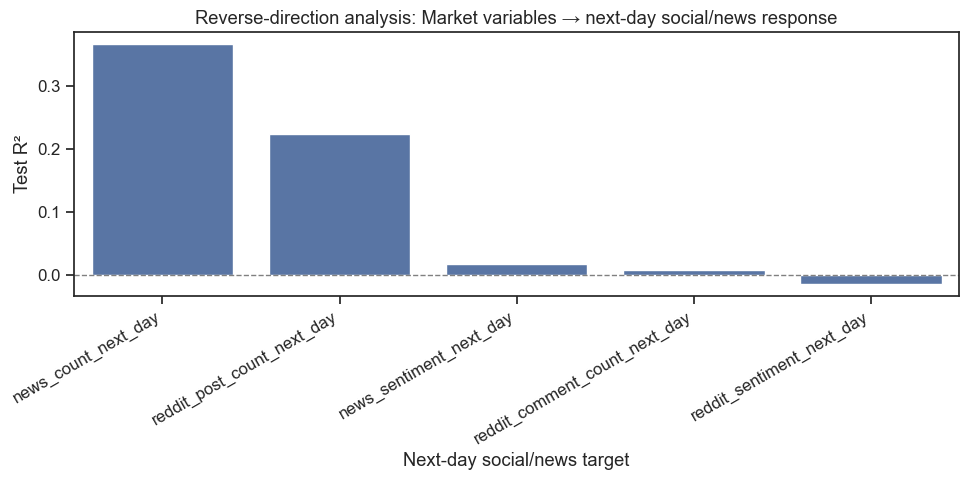

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=reverse_results_df,
    x="target",
    y="r2"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Reverse-direction analysis: Market variables → next-day social/news response")
plt.xlabel("Next-day social/news target")
plt.ylabel("Test R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

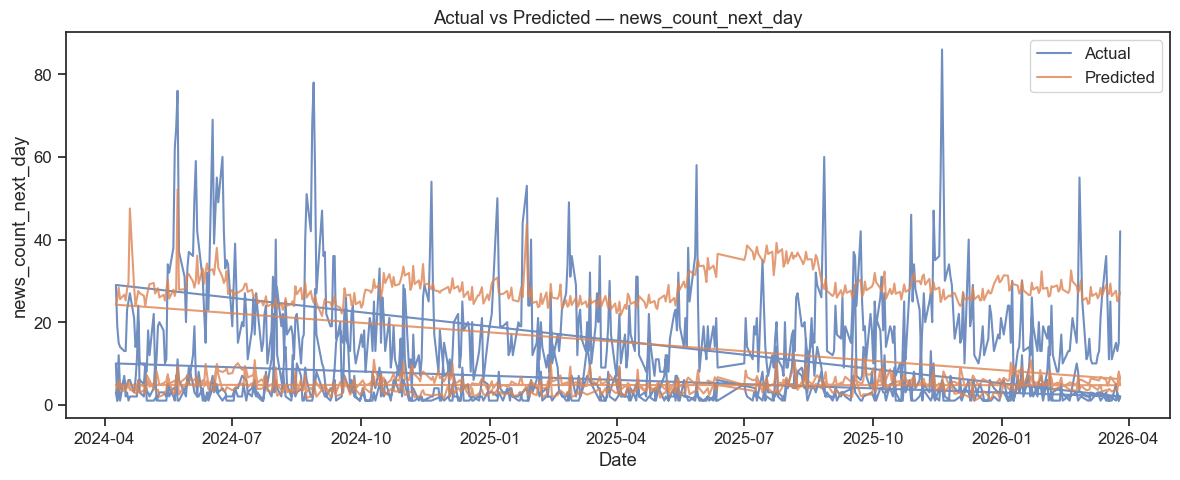

In [13]:
best_target = reverse_results_df.iloc[0]["target"]
best_pred_data = reverse_predictions[best_target]

actual_pred_df = pd.DataFrame({
    "date": best_pred_data["date"].values,
    "actual": best_pred_data["y_test"].values,
    "predicted": best_pred_data["y_pred"]
})

plt.figure(figsize=(12, 5))

plt.plot(
    actual_pred_df["date"],
    actual_pred_df["actual"],
    label="Actual",
    alpha=0.8
)

plt.plot(
    actual_pred_df["date"],
    actual_pred_df["predicted"],
    label="Predicted",
    alpha=0.8
)

plt.title(f"Actual vs Predicted — {best_target}")
plt.xlabel("Date")
plt.ylabel(best_target)
plt.legend()
plt.tight_layout()
plt.show()

*While sentiment and activity features provided little predictive value for future market outcomes, the reverse-direction analysis revealed that market variables contain meaningful information about subsequent media attention. The strongest result was obtained for next-day news coverage (R² = 0.367), followed by Reddit posting activity (R² = 0.224). In contrast, sentiment polarity remained largely unpredictable. These findings suggest that news and social-media activity may primarily reflect investor attention generated by market developments rather than act as reliable predictors of future market behavior.*
